In [63]:
import nd2
import numpy as np
import dask.array as da
import zarr
from numcodecs import Blosc
from skimage import exposure
from scipy.ndimage import gaussian_filter
import os
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

input_dir = Path("/Volumes/data/Sasaki/MTsingleBeads/beads1um/20260717/beads1um003")

MTs_zarr = zarr.open_array(input_dir / "GFP.zarr", mode = 'r')
beads_zarr = zarr.open_array(input_dir / "beads.zarr", mode = 'r')

track = pd.read_csv(input_dir / 'beads_tracks.csv')

5.363636363636363


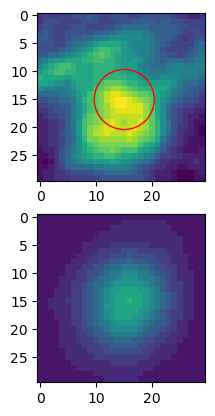

In [125]:
import matplotlib.patches as patches

cargo = 1.18
frame = 100
width =15

num=2

radius = cargo/(2*0.11)
print(radius)

MTs = MTs_zarr[frame]
beads = beads_zarr[frame]

df = track[track['frame'] == frame]

i = min(df.index)+num

MTs_crop = MTs[int(df['y'][i]-width):int(df['y'][i]+width), int(df['x'][i]-width):int(df['x'][i]+width)]
beads_crop = beads[int(df['y'][i]-width):int(df['y'][i]+width), int(df['x'][i]-width):int(df['x'][i]+width)]

c = patches.Circle(xy=(width, width), radius=radius, ec='r', fill=False)

fig, ax =plt.subplots(2)
ax[0].imshow(MTs_crop, vmin = np.min(MTs_crop), vmax = np.max(MTs_crop))
ax[1].imshow(beads_crop, vmin = np.min(beads), vmax = np.max(beads))
ax[0].add_patch(c)
#ax[1].add_patch(c)